<a href="https://colab.research.google.com/github/minhaz-engg/Time-Series-try/blob/main/neuralforecast__NBEATSx.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
%%capture
!pip install neuralforecast

INFO:lightning_fabric.utilities.seed:Seed set to 1
INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


┏━━━┳━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name         ┃ Type          ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ loss         │ MQLoss        │      5 │ train │     0 │
│ 1 │ padder_train │ ConstantPad1d │      0 │ train │     0 │
│ 2 │ scaler       │ TemporalNorm  │      0 │ train │     0 │
│ 3 │ blocks       │ ModuleList    │  3.8 M │ train │     0 │
└───┴──────────────┴───────────────┴────────┴───────┴───────┘

Trainable params: 3.8 M                                                                                            
Non-trainable params: 1.6 K                                                                                        
Total params: 3.8 M                                                                                                
Total estimated model params size (MB): 15                                                                         
Modules in train mode: 52                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)`
is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.

INFO:pytorch_lightning.utilities.rank_zero:Trainer already configured with model summary callbacks: [<class 'pytorch_lightning.callbacks.rich_model_summary.RichModelSummary'>]. Skipping setting a default `ModelSummary` callback.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


Output()

/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


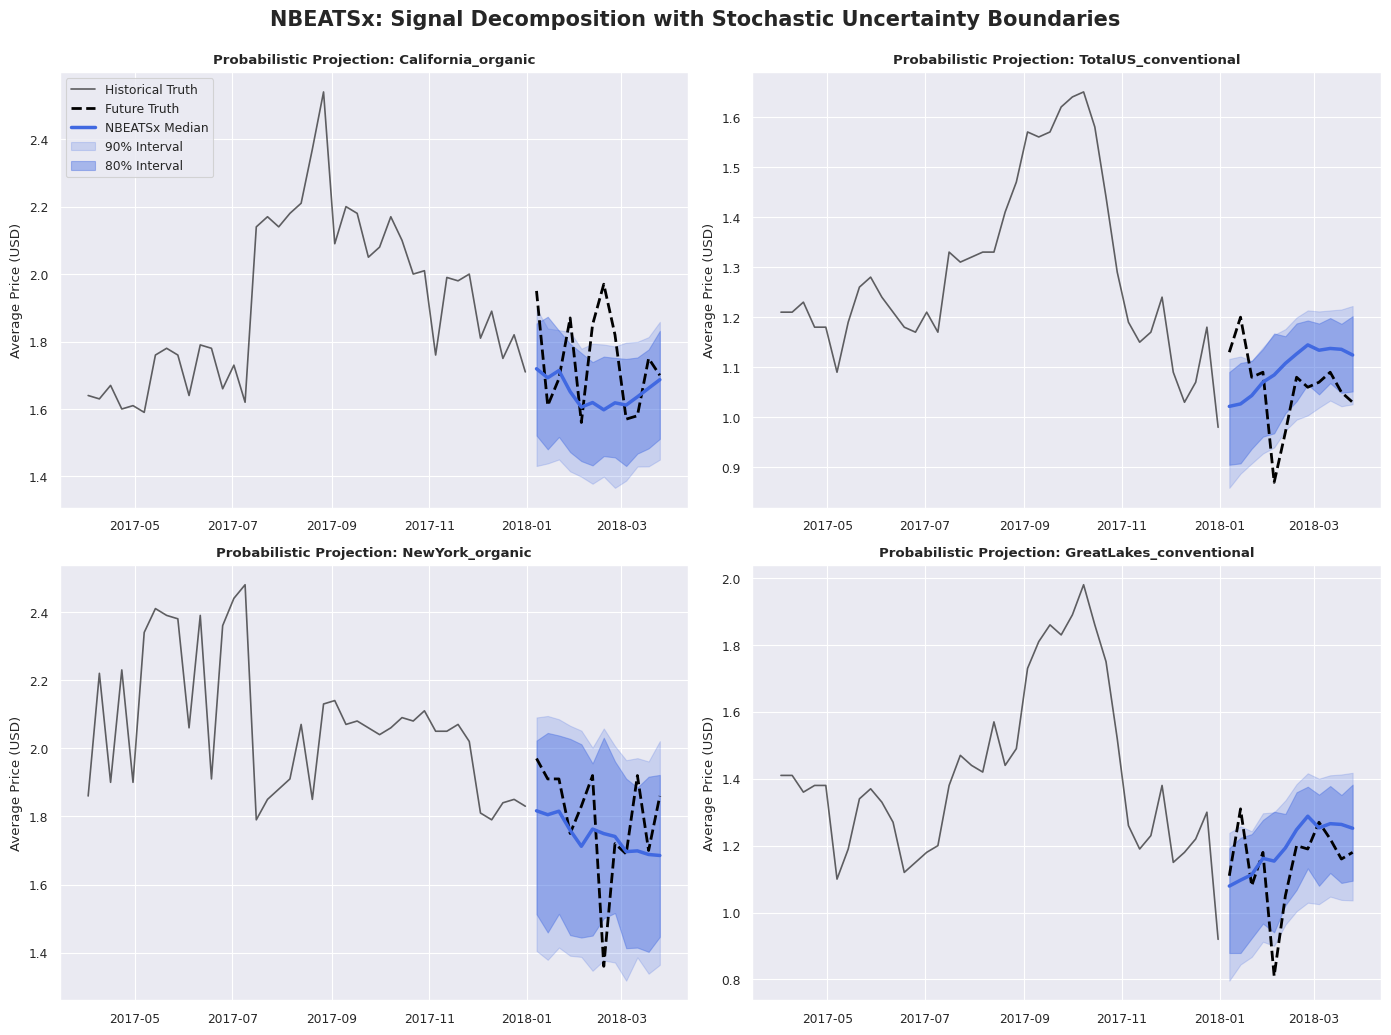

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from neuralforecast import NeuralForecast
from neuralforecast.models import NBEATSx
from neuralforecast.losses.pytorch import MQLoss

# ==========================================
# 1. Ingestion & Topological Restructuring
# ==========================================
url = "https://raw.githubusercontent.com/erkansirin78/datasets/master/avocado.csv"
df = pd.read_csv(url, index_col=0)

# Establish Canonical Schema
df['ds'] = pd.to_datetime(df['Date'])
df['y'] = df['AveragePrice']
df['unique_id'] = df['region'] + "_" + df['type']

# Isolate a representative multidimensional subset
target_regions = ['California', 'NewYork', 'TotalUS', 'GreatLakes']
df = df[df['region'].isin(target_regions)].copy()

# ==========================================
# 2. Exogenous Substrate Engineering
# ==========================================
# A. Deterministic Future (Cyclical Vectors)
df['month'] = df['ds'].dt.month
df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12).astype('float32')
df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12).astype('float32')

# B. Historical Macroeconomics (Log-Normalized Volume)
# We apply np.log1p to compress the massive magnitude of 'Total Volume'
# ensuring stable gradient descent without destroying variance.
df['log_volume'] = np.log1p(df['Total Volume']).astype('float32')

# C. Finalize Dynamic Matrix
df = df.sort_values(['unique_id', 'ds']).reset_index(drop=True)
Y_df = df[['unique_id', 'ds', 'y', 'month_sin', 'month_cos', 'log_volume']]

# D. Immutable Static Embeddings
static_df = df[['unique_id', 'type', 'region']].drop_duplicates().reset_index(drop=True)
static_df['is_organic'] = (static_df['type'] == 'organic').astype(np.float32)
region_map = {reg: i for i, reg in enumerate(target_regions)}
static_df['region_enc'] = static_df['region'].map(region_map).astype(np.float32)
static_df = static_df[['unique_id', 'is_organic', 'region_enc']]

# ==========================================
# 3. Temporal Bifurcation (Train/Test)
# ==========================================
horizon = 12 # Predict 12 weeks into the future
global_max_date = Y_df['ds'].max()
cutoff_date = global_max_date - pd.Timedelta(weeks=horizon)

Y_train_df = Y_df[Y_df['ds'] <= cutoff_date].reset_index(drop=True)
Y_test_df = Y_df[Y_df['ds'] > cutoff_date].reset_index(drop=True)

# ==========================================
# 4. NBEATSx Probabilistic Initialization
# ==========================================
model = NBEATSx(
    h=horizon,
    input_size=52,            # 52-week receptive field
    loss=MQLoss(level=[80, 90]), # Multi-Quantile optimization for probabilistic bounds
    scaler_type='robust',
    dropout_prob_theta=0.3,   # Regularization to prevent structural overfitting
    stat_exog_list=['is_organic', 'region_enc'],
    futr_exog_list=['month_sin', 'month_cos'],
    hist_exog_list=['log_volume'], # The network now 'sees' historical supply shock

    # The Core Signal Decomposition Strategy:
    stack_types=["identity", "trend", "seasonality", "exogenous"],
    n_blocks=[1, 1, 1, 1],    # One neural block dedicated to each signal component

    max_steps=300,
    val_check_steps=10,
    early_stop_patience_steps=3
)

nf = NeuralForecast(models=[model], freq='W')

# Execute optimization
nf.fit(df=Y_train_df, static_df=static_df, val_size=horizon)

# Inference projection
Y_hat_df = nf.predict(futr_df=Y_test_df)

# ==========================================
# 5. Probabilistic Empirical Visualization
# ==========================================
Y_hat_df = Y_hat_df.reset_index(drop=False)
merged_plot_df = pd.merge(Y_test_df, Y_hat_df, on=['unique_id', 'ds'], how='inner')

# Configure visualization paradigm
sns.set_theme(style="darkgrid", context="paper")
fig, axes = plt.subplots(2, 2, figsize=(14, 10), sharex=False)
axes = axes.flatten()

# Select a subset of unique IDs for rigorous visual inspection
sample_uids = ['California_organic', 'TotalUS_conventional', 'NewYork_organic', 'GreatLakes_conventional']

for idx, uid in enumerate(sample_uids):
    ax = axes[idx]

    train_subset = Y_train_df[Y_train_df['unique_id'] == uid].tail(40) # Last 40 weeks for context
    test_subset = merged_plot_df[merged_plot_df['unique_id'] == uid]

    # Historical ground truth
    ax.plot(train_subset['ds'], train_subset['y'], color='black', alpha=0.6, label='Historical Truth')

    # Future ground truth
    ax.plot(test_subset['ds'], test_subset['y'], color='black', linestyle='--', linewidth=2, label='Future Truth')

    # Probabilistic Median (The P50 expectation)
    ax.plot(test_subset['ds'], test_subset['NBEATSx-median'], color='royalblue', linewidth=2.5, label='NBEATSx Median')

    # Epistemic Uncertainty Boundaries (90% Confidence Interval)
    ax.fill_between(test_subset['ds'],
                    test_subset['NBEATSx-lo-90'],
                    test_subset['NBEATSx-hi-90'],
                    color='royalblue', alpha=0.2, label='90% Interval')

    # Narrower Uncertainty Boundary (80% Confidence Interval)
    ax.fill_between(test_subset['ds'],
                    test_subset['NBEATSx-lo-80'],
                    test_subset['NBEATSx-hi-80'],
                    color='royalblue', alpha=0.4, label='80% Interval')

    ax.set_title(f"Probabilistic Projection: {uid}", fontweight='bold')
    ax.set_ylabel("Average Price (USD)")

    if idx == 0:
        ax.legend(loc='upper left', frameon=True)

plt.tight_layout()
plt.suptitle("NBEATSx: Signal Decomposition with Stochastic Uncertainty Boundaries", y=1.03, fontsize=15, fontweight='bold')
plt.show()